<a href="https://colab.research.google.com/github/ojaspaul123/DL-journey/blob/main/ANN/ReLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Variants of ReLU (Leaky ReLU, PReLU, ELU)**

While the standard Rectified Linear Unit (ReLU) is widely used and often performs well, its characteristic of outputting exactly zero for all negative inputs can lead to a problem known as the "dying ReLU". If a neuron's weights are updated such that its input consistently falls into the negative range, it will always output zero. Consequently, the gradient flowing through that neuron during backpropagation will also be zero, effectively preventing its weights from being updated further. The neuron becomes inactive.

To address this potential issue and explore alternative non-linearities, several variants of ReLU have been proposed. These variants maintain the benefits of ReLU for positive inputs but introduce a small slope for negative inputs, ensuring that gradients can still flow even when the unit is not strongly activated.

**Leaky ReLU**

The Leaky ReLU is one of the simplest modifications. Instead of outputting zero for negative inputs, it outputs a small, negative value proportional to the input. Mathematically, it's defined as:
f(x)={xif x>0αxif x≤0
f(x)={xαx​if x>0if x≤0​

Here, αα is a small, fixed hyperparameter, typically set to a value like 0.01. The main idea is that the function now has a non-zero gradient (αα) for negative inputs. This small gradient ensures that neurons don't completely "die" and remain capable of learning.


**Parametric ReLU (PReLU)**

Parametric ReLU, or PReLU, takes the idea of Leaky ReLU a step further. Instead of using a fixed value for the slope αα in the negative region, PReLU treats αα as a learnable parameter. This means the network itself can learn the optimal slope for negative inputs during the training process through backpropagation.
f(x)={xif x>0αxif x≤0(α is learned)
f(x)={xαx​if x>0if x≤0(α is learned)​

PReLU can potentially offer better performance than Leaky ReLU if the optimal slope is different from the pre-defined small constant, but it adds one extra parameter per neuron (or per channel in convolutional layers) that needs to be learned. If data is limited, this could slightly increase the risk of overfitting compared to Leaky ReLU or standard ReLU.


**Exponential Linear Unit (ELU)**

The Exponential Linear Unit (ELU) offers another alternative, aiming to push activation means closer to zero, which can sometimes speed up learning. For positive inputs, it behaves like ReLU. For negative inputs, it uses an exponential function that saturates to a negative value.
f(x)={xif x>0α(ex−1)if x≤0
f(x)={xα(ex−1)​if x>0if x≤0​

The hyperparameter αα controls the value to which ELU saturates for negative inputs (commonly set to 1.0). Unlike Leaky ReLU and PReLU, ELU can produce negative outputs. It also has a smoother transition around x=0x=0 compared to the sharp corner of ReLU and its leaky variants (though the gradient is not continuous at x=0x=0 unless α=1α=1). The potential benefit of pushing activations towards a zero mean comes at the cost of a slightly higher computational expense due to the exponential function.

**Visual Comparison**

The following chart compares the shapes of ReLU and its common variants:

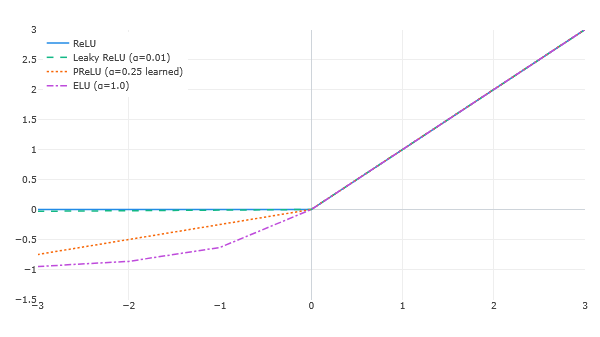

    Comparison of ReLU, Leaky ReLU (with a typical small alpha), PReLU (representing a potentially learned larger alpha), and ELU. Note how Leaky ReLU and PReLU have linear negative slopes, while ELU has a smooth curve saturating towards -alpha.

Choosing Between Variants

While standard ReLU remains a very common and often effective choice, especially as a starting point, these variants provide useful alternatives:

    Leaky ReLU: A simple fix for potential dying ReLU issues. Use it if you observe many inactive neurons during training with standard ReLU.
    PReLU: Use it if you believe the optimal negative slope might differ significantly from small constants like 0.01 and you have sufficient data to learn the extra parameters without overfitting.
    ELU: Can be beneficial if pushing activations closer to zero mean is desirable, potentially leading to faster convergence. Its smoother curve for negative inputs and negative saturation are distinct properties. However, it's computationally slightly more intensive than ReLU or Leaky ReLU.

In practice, the choice often comes down to empirical testing. Try standard ReLU first, and if performance is lacking or dying neurons are suspected, experiment with Leaky ReLU, PReLU, or ELU to see if they provide an improvement for your specific task and architecture.